# O1 deterministic: 5,000-trial depth-policy study

Loads the five fixed-depth controls, compact Mistral policy, and the chronological 80/20 holdout RF-selection policy. Lower final best-so-far objective is better.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() / 'results'
if not ROOT.exists(): ROOT = Path('results')
FIXED = [5, 10, 20, 30, 20000]
POLICIES = [*(f'fixed_depth_{d}_100_trees_split_2_leaf_1' for d in FIXED),
            'rwthgpt_mistral_compact_fixed_100_trees_5000',
            'chronological_holdout_rf_selection_5000']
LABELS = {**{f'fixed_depth_{d}_100_trees_split_2_leaf_1': f'fixed depth {d}' for d in FIXED},
          'rwthgpt_mistral_compact_fixed_100_trees_5000': 'compact Mistral',
          'chronological_holdout_rf_selection_5000': 'chronological 80/20 holdout'}

rows, trajectories = [], []
for path in ROOT.glob('dimension_*/benchmark_seed_40/*/*/trajectory.json'):
    payload = json.loads(path.read_text())
    policy = payload.get('policy')
    if policy not in POLICIES: continue
    dimension, seed = int(payload['dimension']), int(payload['smac_seed'])
    best = np.asarray(payload['best_so_far'], dtype=float)
    rows.append({'dimension': dimension, 'seed': seed, 'policy': policy, 'label': LABELS[policy],
                 'finished_trials': payload['finished_trials'], 'final_best_so_far': best[-1]})
    trajectories.extend({'dimension':dimension, 'seed':seed, 'policy':policy, 'label':LABELS[policy],
                         'trial':trial, 'best_so_far':value}
                        for trial, value in enumerate(best, 1))
finals = pd.DataFrame(rows); curves = pd.DataFrame(trajectories)
print(f'{len(finals)} complete trajectories loaded')
finals.groupby(['dimension','label']).agg(n=('seed','size'), mean=('final_best_so_far','mean'), std=('final_best_so_far','std')).round(5)

280 complete trajectories loaded


n          mean           std
dimension label                                                      
10        chronological 80/20 holdout  10 -2.246541e+05     899.16616
          compact Mistral              10 -2.227350e+05    1497.56754
          fixed depth 10               10 -2.223813e+05    1463.83114
          fixed depth 20               10 -2.233869e+05    1280.05714
          fixed depth 20000            10 -2.244675e+05     763.32108
          fixed depth 30               10 -2.243384e+05     917.33934
          fixed depth 5                10 -2.129461e+05    2750.79794
25        chronological 80/20 holdout  10 -5.796785e+05    1759.95631
          compact Mistral              10 -5.542998e+05   16930.47977
          fixed depth 10               10 -5.547453e+05    7542.64314
          fixed depth 20               10 -5.700984e+05    4858.38518
          fixed depth 20000            10 -5.794077e+05    2064.17854
          fixed depth 30               10 -5.774429e+05    2628.72970
          fixed depth 5                10 -5.145490e+05    7907.57514
50        chronological 80/20 holdout  10 -1.229960e+06   10525.59712
          compact Mistral              10 -1.181912e+06   48352.68524
          fixed depth 10               10 -1.111972e+06   28199.82907
          fixed depth 20               10 -1.205754e+06   15442.43286
          fixed depth 20000            10 -1.229588e+06   11821.45055
          fixed depth 30               10 -1.233751e+06   14331.66507
          fixed depth 5                10 -9.845165e+05   40736.64993
100       chronological 80/20 holdout  10 -2.042230e+06   62992.37318
          compact Mistral              10 -1.894499e+06  145219.26908
          fixed depth 10               10 -1.737267e+06   65635.90351
          fixed depth 20               10 -2.006619e+06   47446.83003
          fixed depth 20000            10 -2.027484e+06   55817.04043
          fixed depth 30               10 -2.029062e+06   47697.87864
          fixed depth 5                10 -1.476978e+06   90315.35753

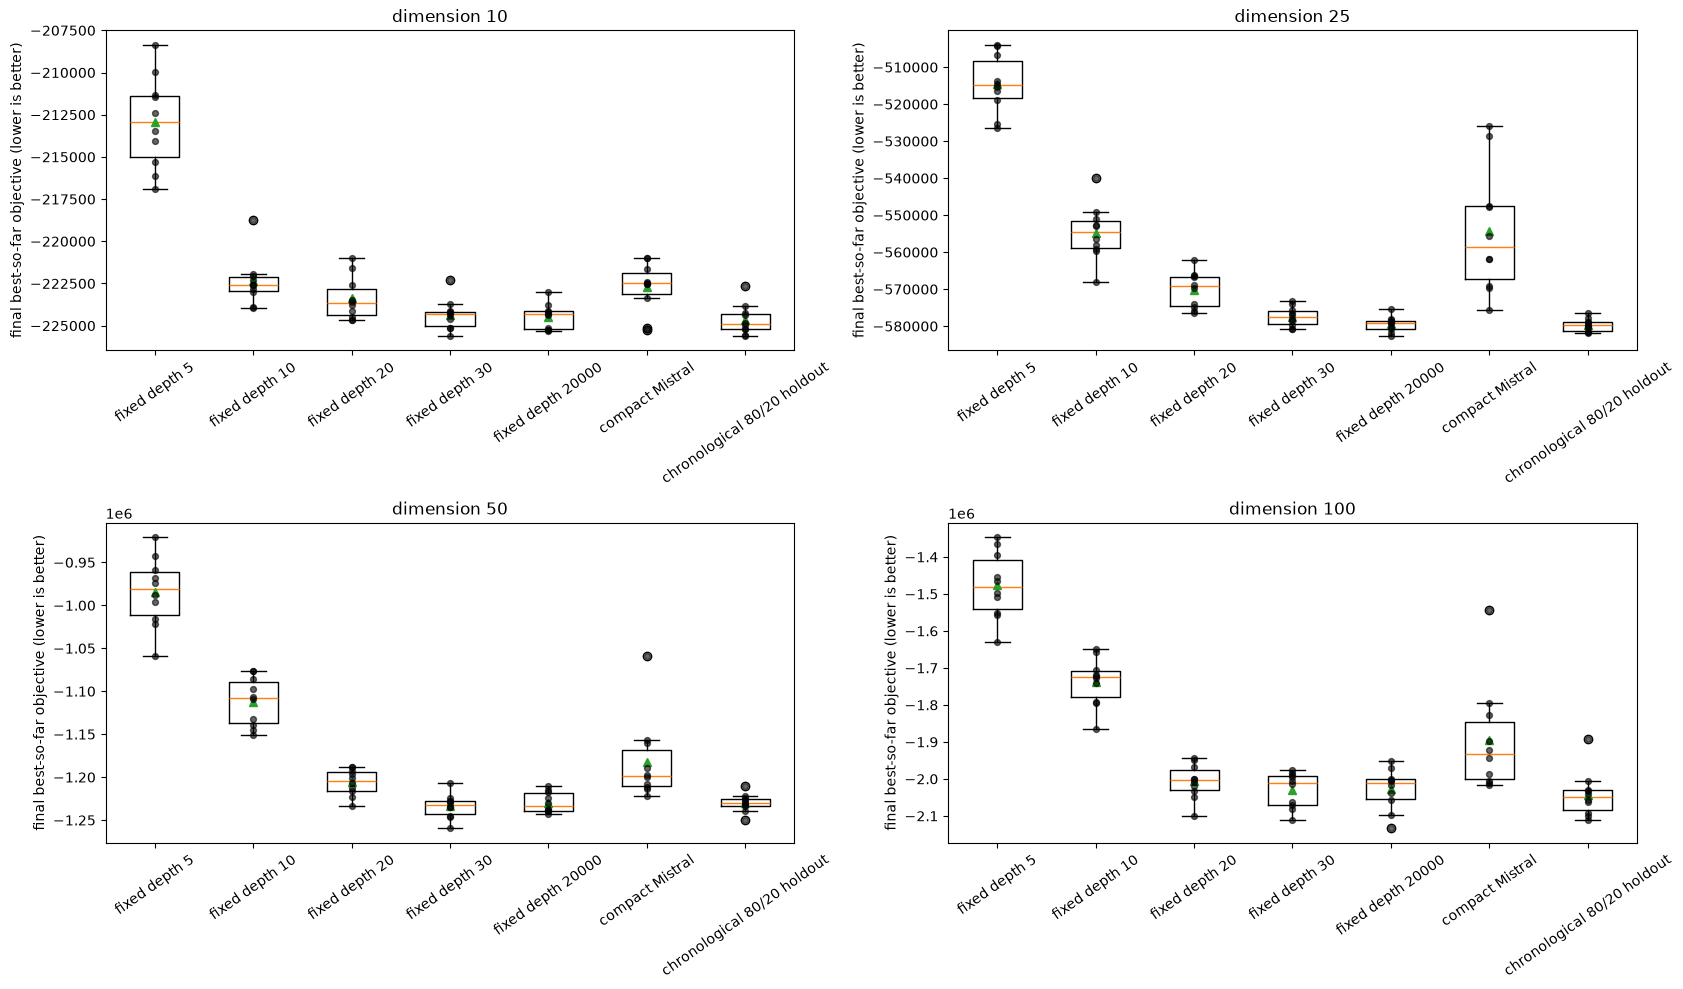

In [2]:
# Final incumbent/best-so-far distributions, one panel per dimension.
fig, axes = plt.subplots(2, 2, figsize=(17, 10), sharey=False)
for ax, dimension in zip(axes.flat, (10, 25, 50, 100)):
    data = finals[finals.dimension == dimension]
    order = [LABELS[p] for p in POLICIES]
    values = [data.loc[data.label == label, 'final_best_so_far'].to_numpy() for label in order]
    ax.boxplot(values, tick_labels=order, showmeans=True)
    for index, value in enumerate(values, 1):
        ax.scatter(np.full(len(value), index), value, color='black', alpha=.6, s=18, zorder=3)
    ax.set_title(f'dimension {dimension}')
    ax.set_ylabel('final best-so-far objective (lower is better)')
    ax.tick_params(axis='x', rotation=35)
fig.tight_layout()

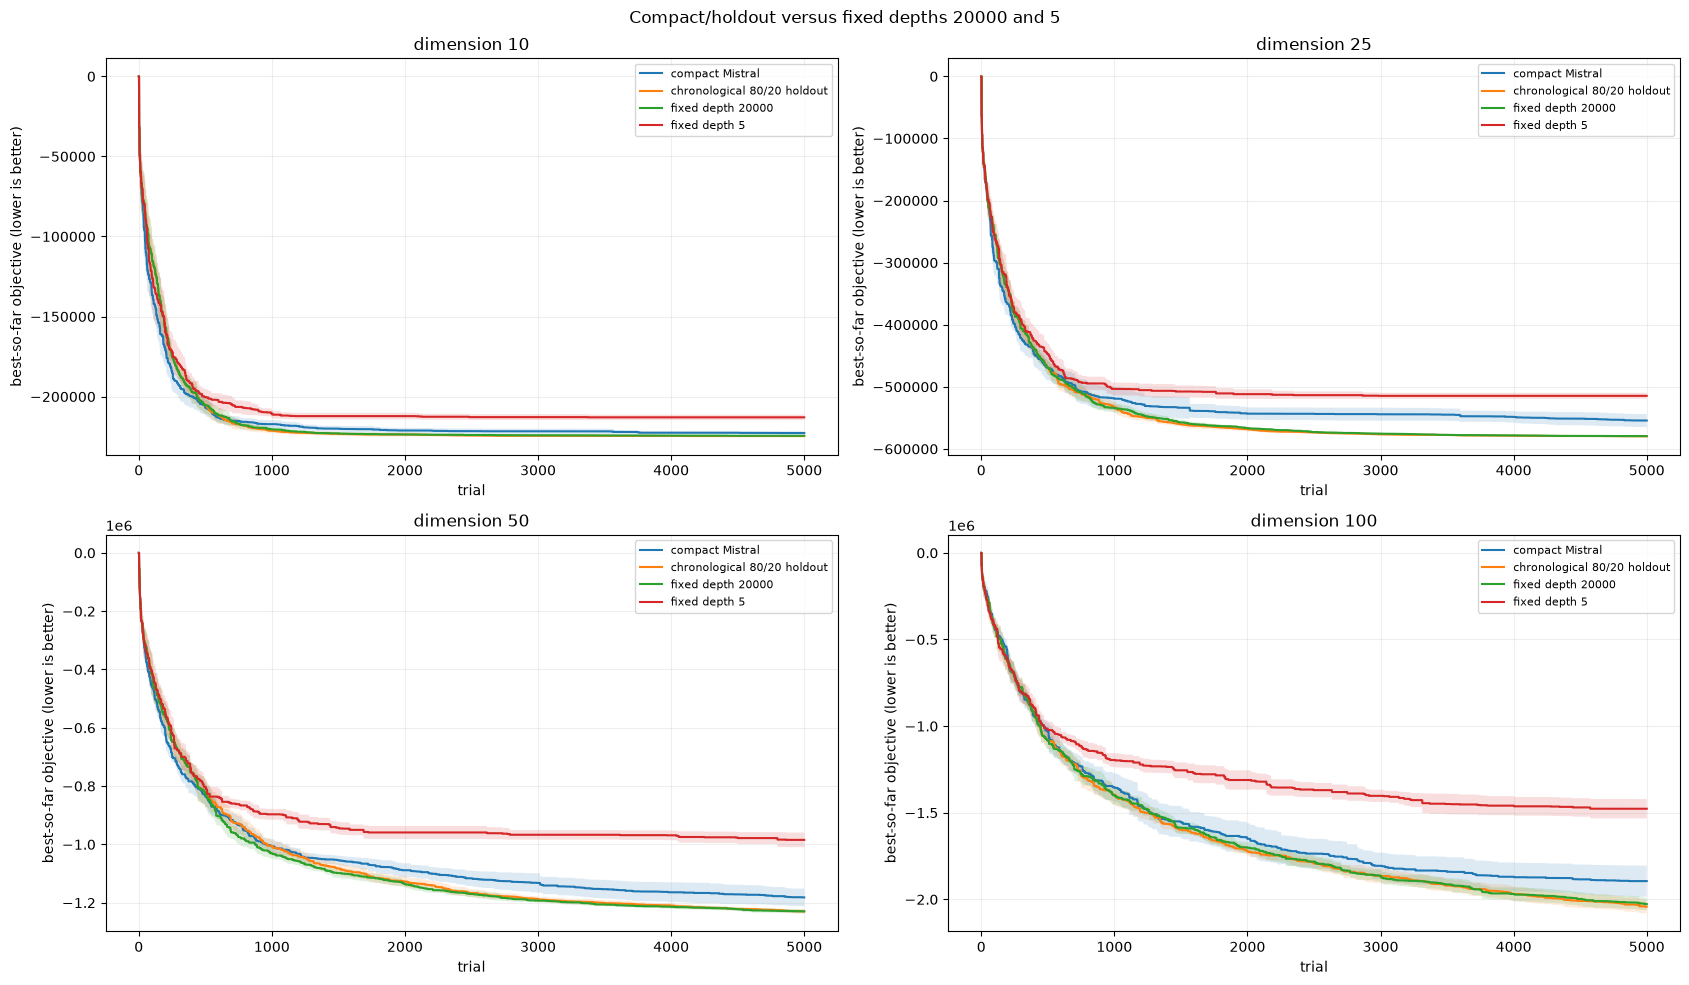

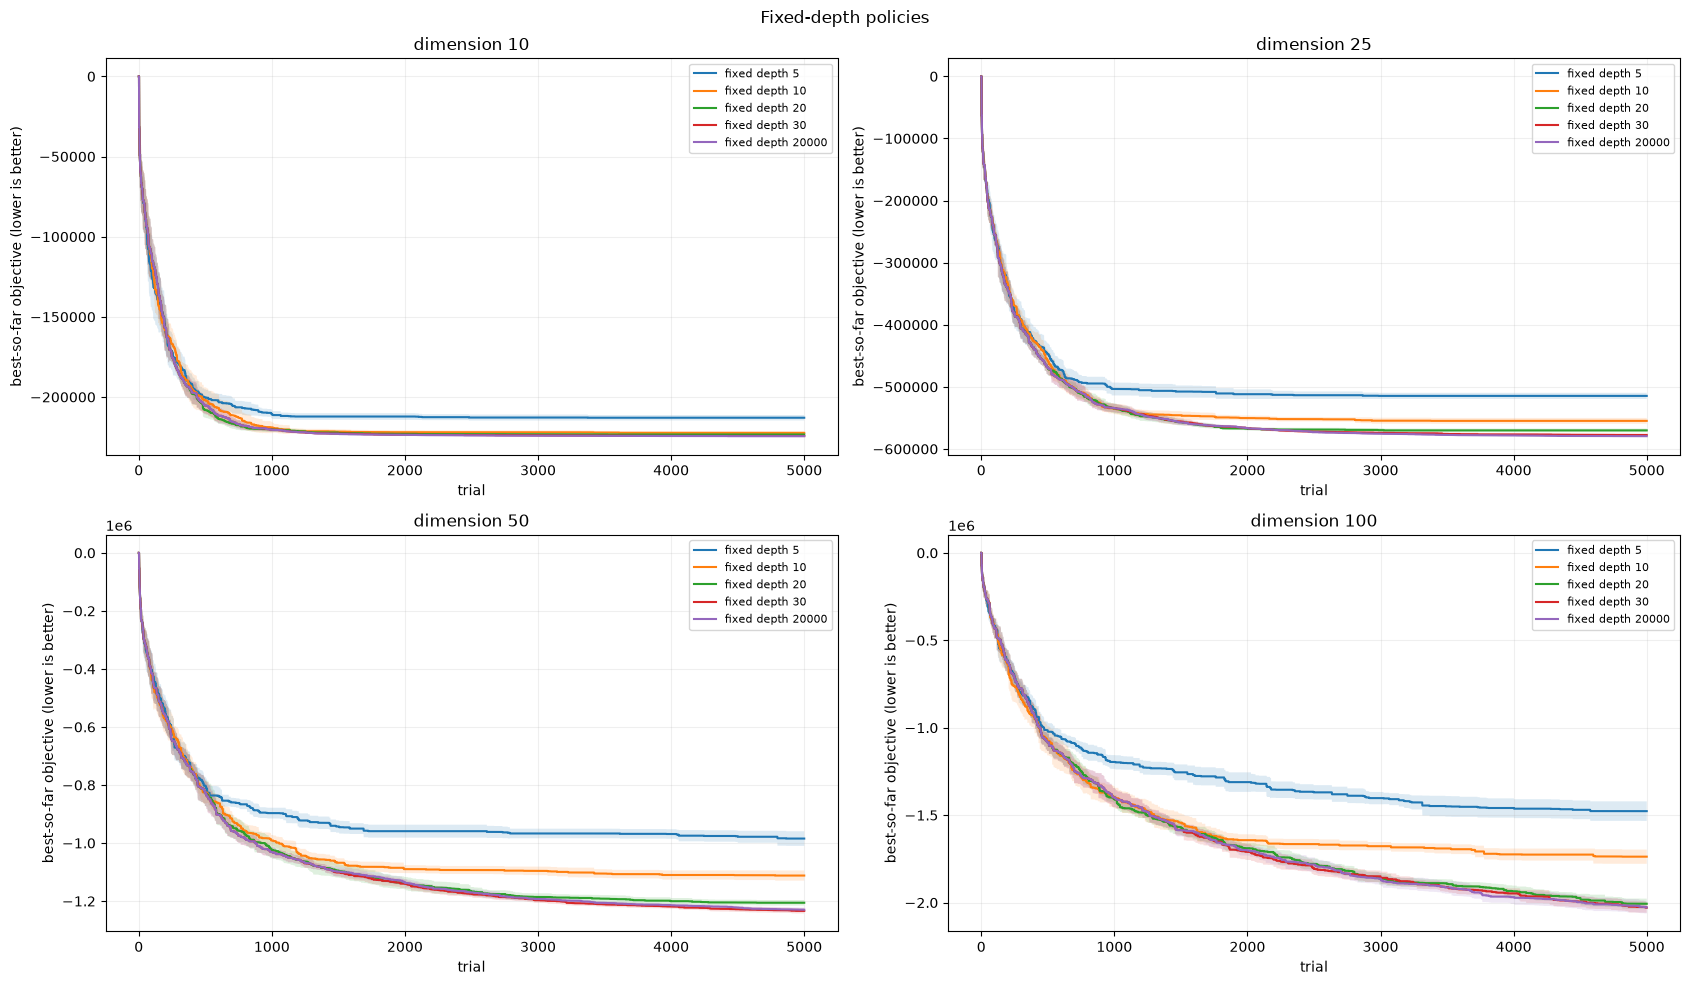

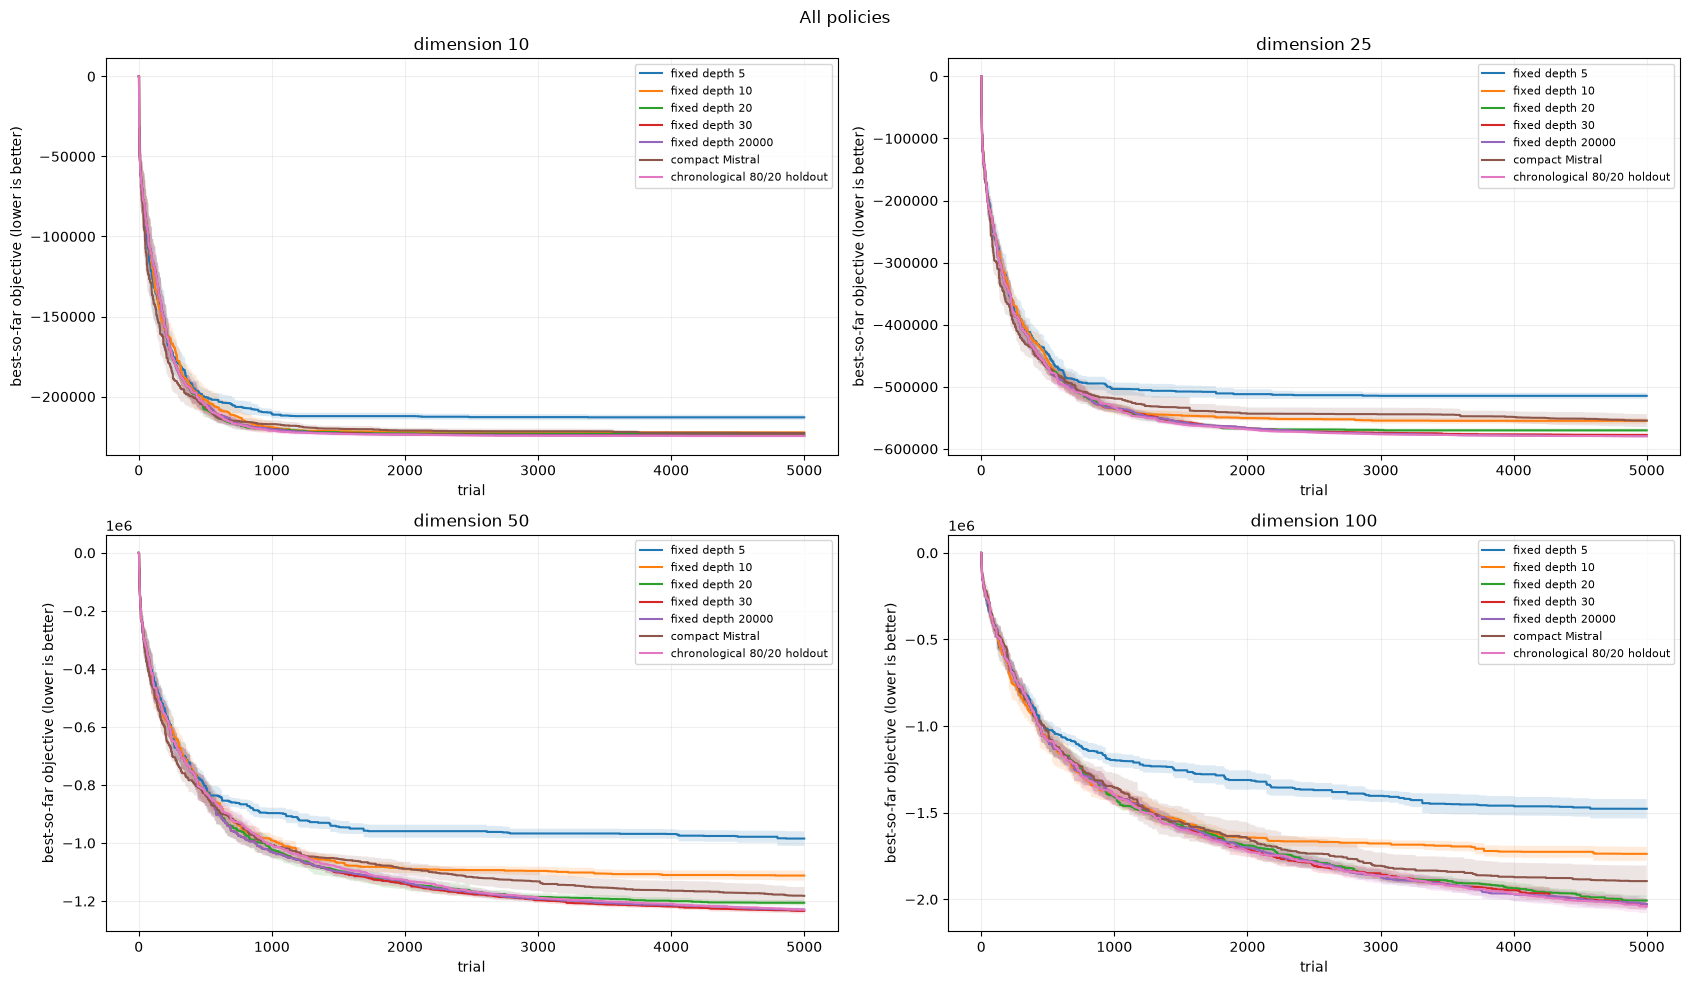

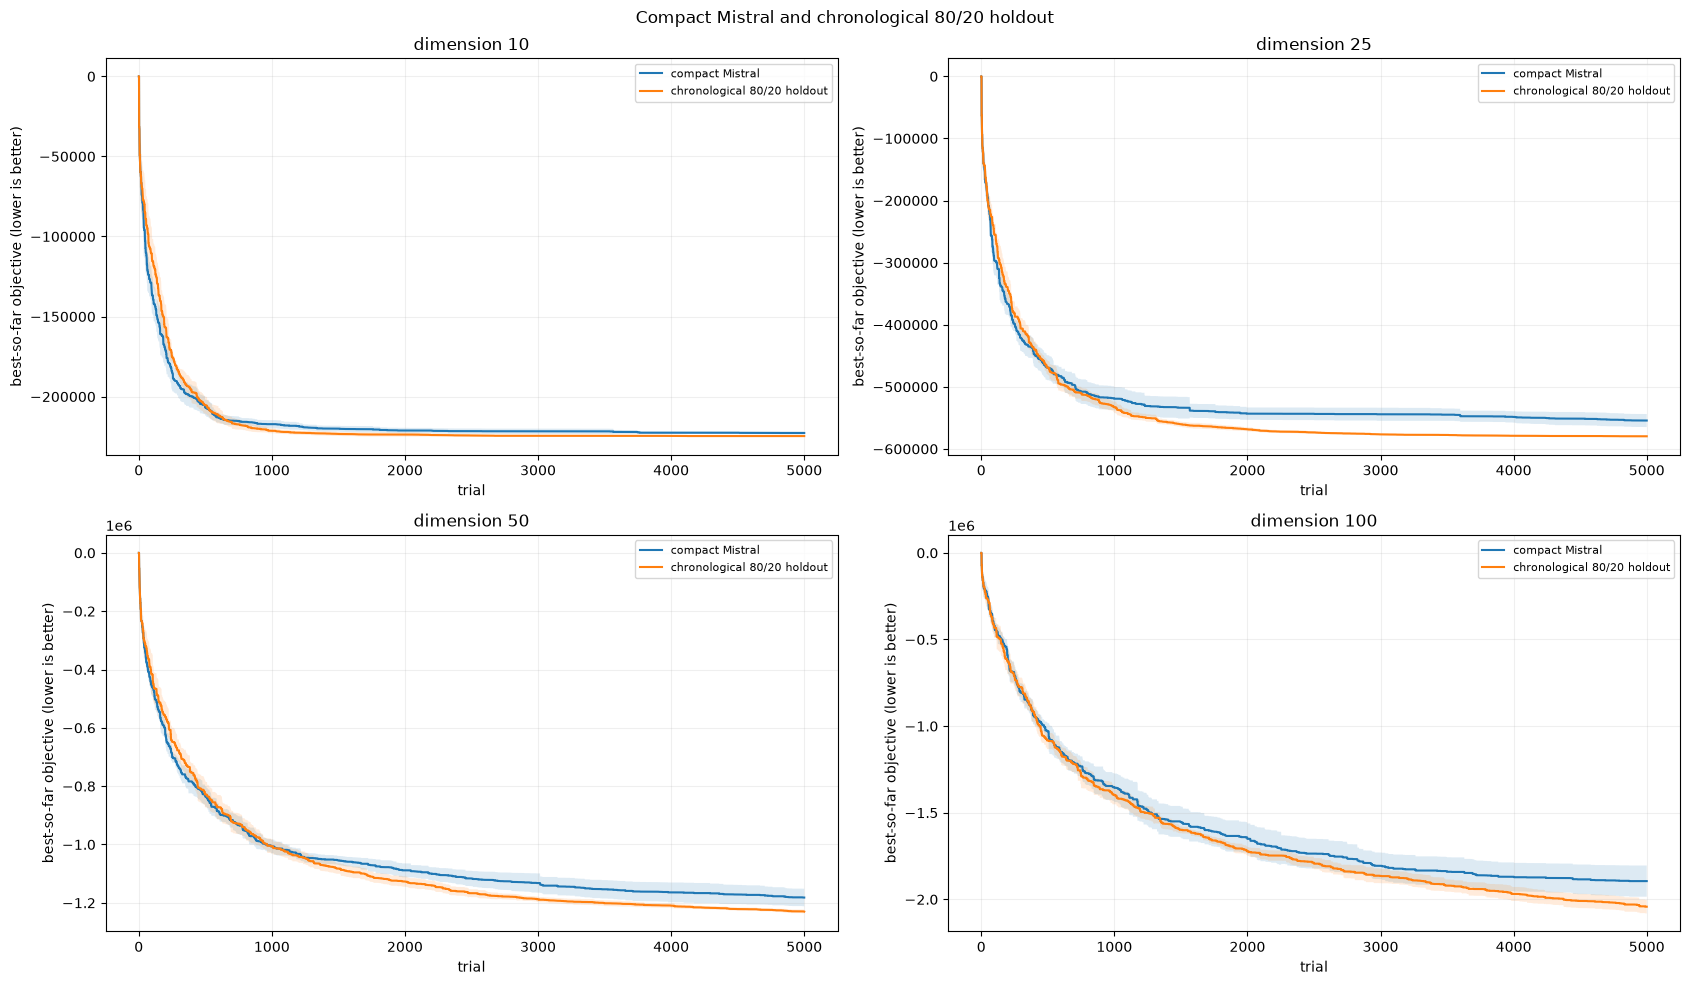

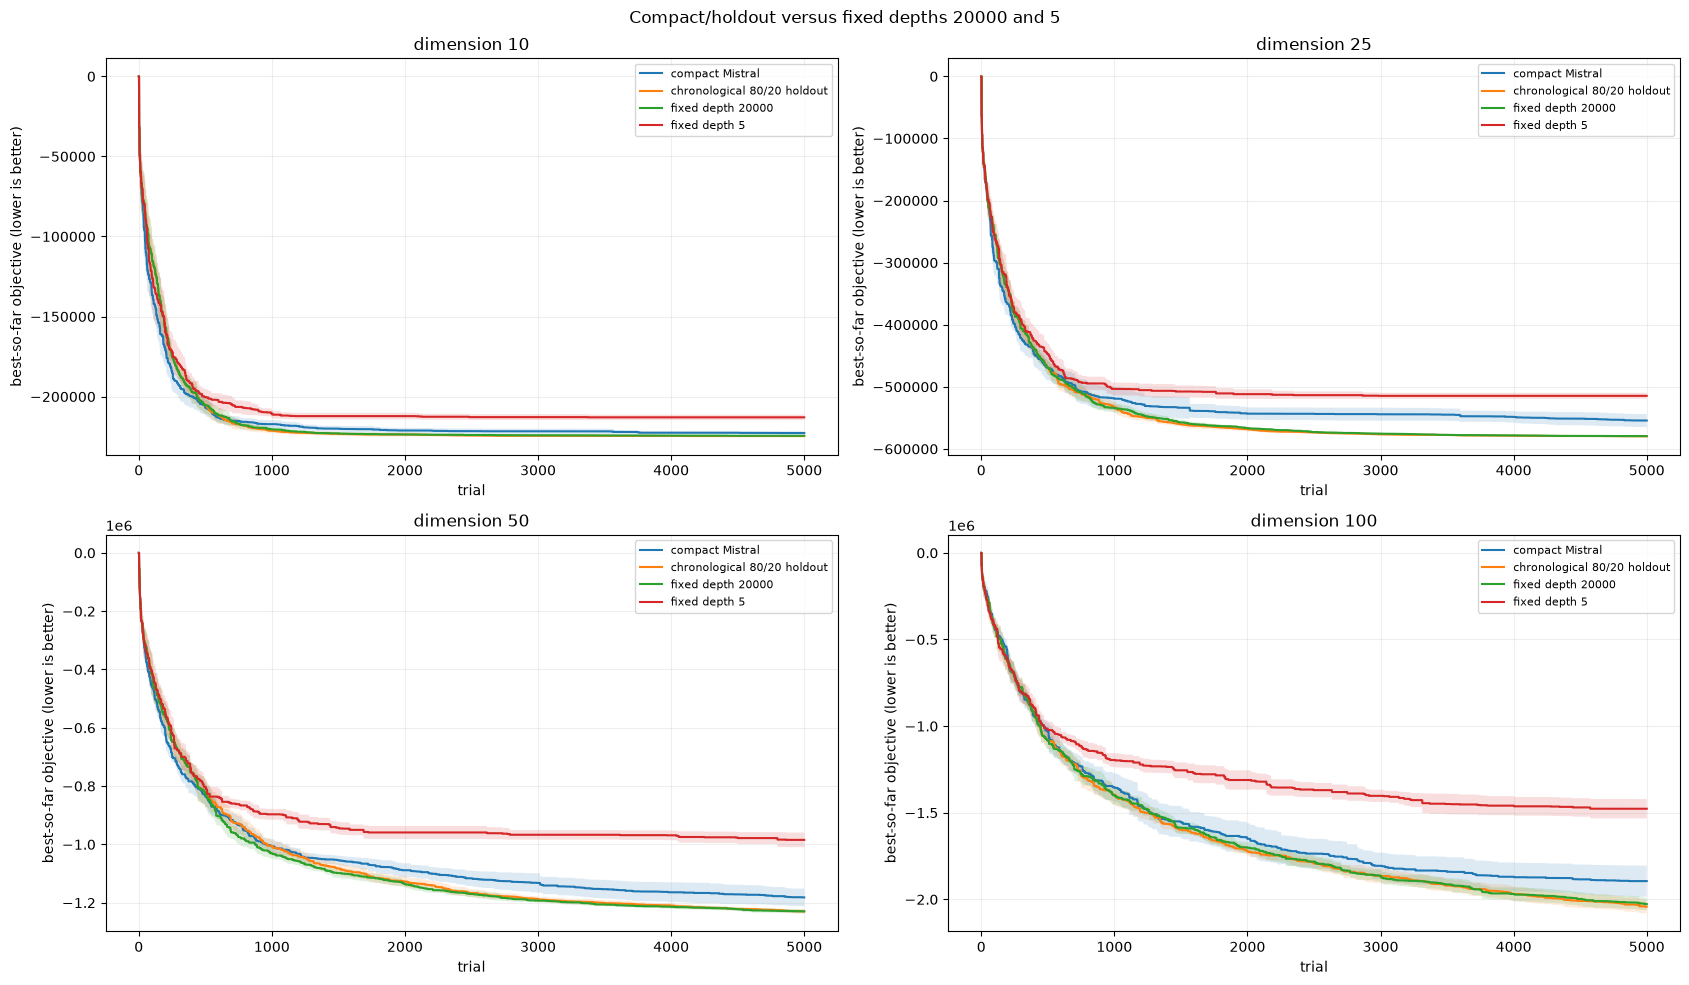

In [3]:
# Mean best-so-far trajectories with 95% confidence intervals across SMAC seeds.
# The band is mean +/- 1.96 * standard error at each trial.
def plot_best_so_far_ci(policy_subset, title):
    fig, axes = plt.subplots(2, 2, figsize=(17, 10), sharey=False)
    for ax, dimension in zip(axes.flat, (10, 25, 50, 100)):
        for policy in policy_subset:
            data = curves[(curves.dimension == dimension) & (curves.policy == policy)]
            if data.empty: continue
            matrix = data.pivot_table(index='trial', columns='seed', values='best_so_far', aggfunc='last').sort_index()
            mean = matrix.mean(axis=1)
            count = matrix.count(axis=1)
            sem = matrix.std(axis=1, ddof=1).fillna(0) / np.sqrt(count.clip(lower=1))
            ci = 1.96 * sem
            ax.plot(mean.index, mean.values, label=LABELS[policy], linewidth=1.5)
            ax.fill_between(mean.index, (mean-ci).values, (mean+ci).values, alpha=.15)
        ax.set_title(f'dimension {dimension}')
        ax.set_xlabel('trial')
        ax.set_ylabel('best-so-far objective (lower is better)')
        ax.grid(alpha=.2)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig

plot_best_so_far_ci([p for p in POLICIES if p.startswith('fixed_depth_')], 'Fixed-depth policies')
plot_best_so_far_ci(POLICIES, 'All policies')
plot_best_so_far_ci(['rwthgpt_mistral_compact_fixed_100_trees_5000', 'chronological_holdout_rf_selection_5000'], 'Compact Mistral and chronological 80/20 holdout')
plot_best_so_far_ci(['rwthgpt_mistral_compact_fixed_100_trees_5000', 'chronological_holdout_rf_selection_5000', 'fixed_depth_20000_100_trees_split_2_leaf_1', 'fixed_depth_5_100_trees_split_2_leaf_1'], 'Compact/holdout versus fixed depths 20000 and 5')

Mean incumbent value and rank by dimension (values averaged across SMAC seeds):


,dimension,label,mean_incumbent_value,rank,seed_count
0,10,chronological 80/20 holdout,-2.165980e+05,1.0,10
4,10,fixed depth 20000,-2.162848e+05,2.0,10
5,10,fixed depth 30,-2.161763e+05,3.0,10
3,10,fixed depth 20,-2.157693e+05,4.0,10
1,10,compact Mistral,-2.153554e+05,5.0,10
2,10,fixed depth 10,-2.144624e+05,6.0,10
6,10,fixed depth 5,-2.063804e+05,7.0,10
7,25,chronological 80/20 holdout,-5.432429e+05,1.0,10
11,25,fixed depth 20000,-5.421941e+05,2.0,10
12,25,fixed depth 30,-5.413765e+05,3.0,10


Ranking table and average rank across dimensions:


dimension,10,25,50,100,average_rank
label,,,,,
chronological 80/20 holdout,1.0,1.0,4.0,1.0,1.75
fixed depth 20000,2.0,2.0,2.0,2.0,2.00
fixed depth 30,3.0,3.0,1.0,3.0,2.50
fixed depth 20,4.0,4.0,3.0,4.0,3.75
compact Mistral,5.0,6.0,5.0,5.0,5.25
fixed depth 10,6.0,5.0,6.0,6.0,5.75
fixed depth 5,7.0,7.0,7.0,7.0,7.00


label,chronological 80/20 holdout,compact Mistral,fixed depth 10,fixed depth 20,fixed depth 20000,fixed depth 30,fixed depth 5
dimension,,,,,,,
10,-2.165980e+05,-2.153554e+05,-2.144624e+05,-2.157693e+05,-2.162848e+05,-2.161763e+05,-2.063804e+05
25,-5.432429e+05,-5.215382e+05,-5.260814e+05,-5.385292e+05,-5.421941e+05,-5.413765e+05,-4.926670e+05
50,-1.083669e+06,-1.054191e+06,-1.024281e+06,-1.083907e+06,-1.091774e+06,-1.095394e+06,-9.128947e+05
100,-1.652485e+06,-1.590103e+06,-1.523585e+06,-1.636849e+06,-1.646941e+06,-1.645979e+06,-1.284584e+06


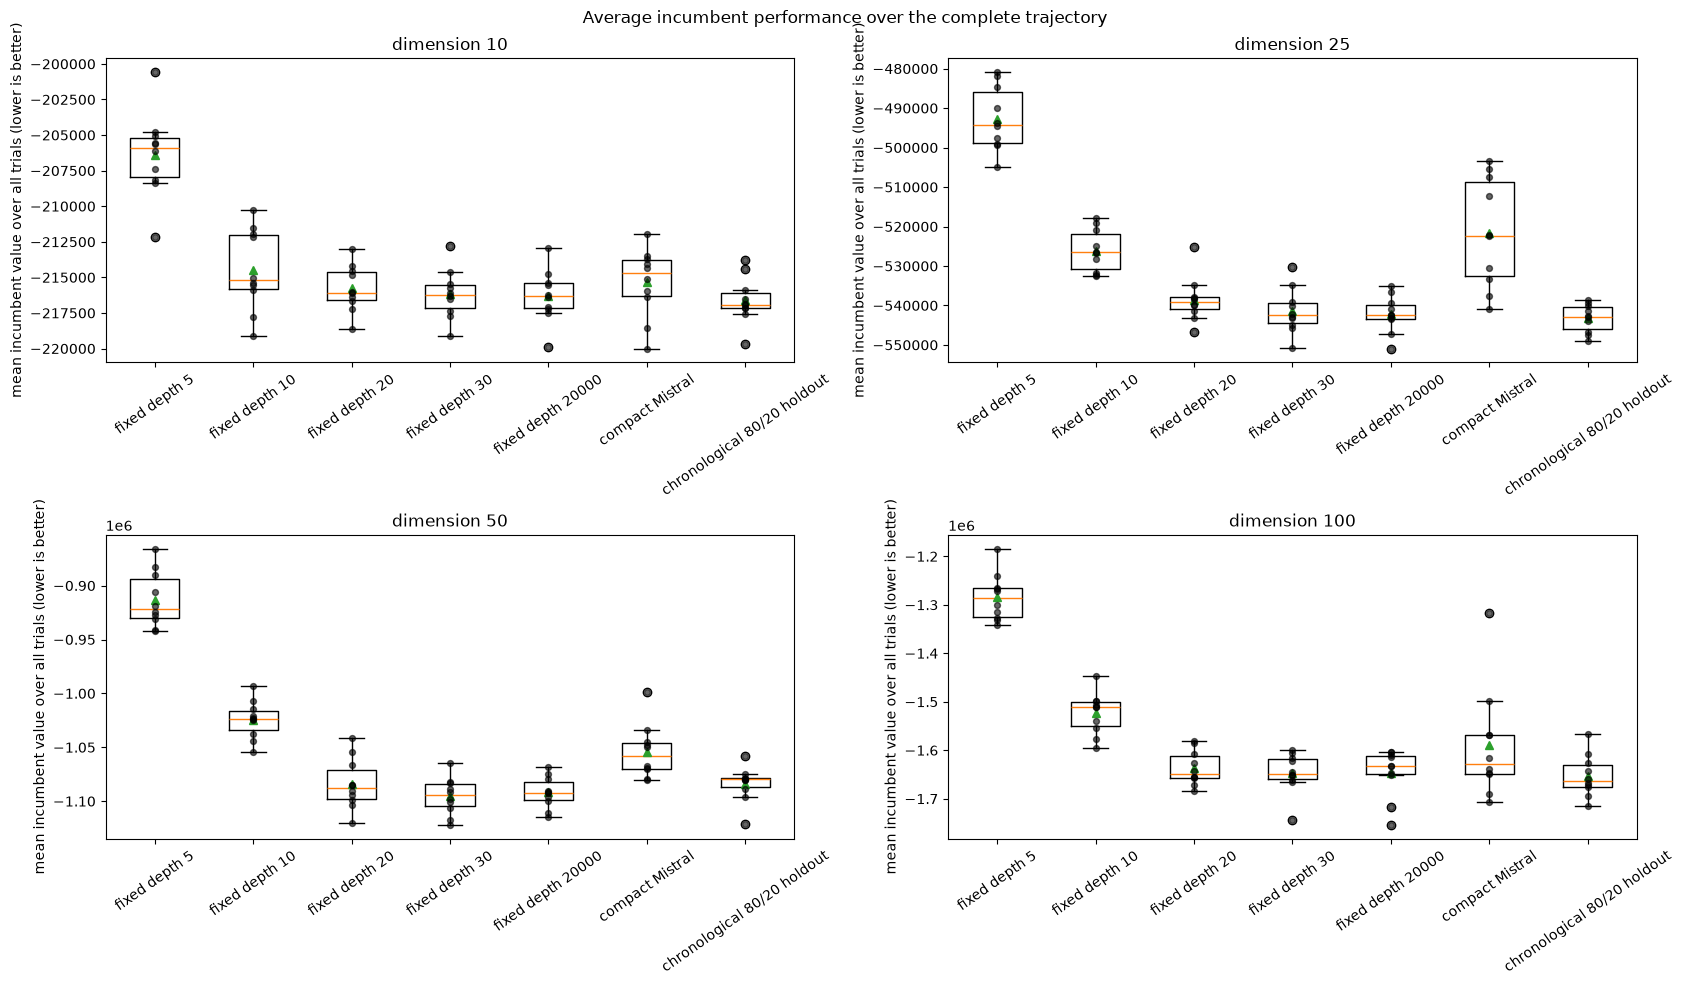

In [4]:
# Mean incumbent value over the entire run, per seed. Lower is better.
mean_incumbent = (curves.groupby(['dimension', 'seed', 'policy', 'label'], as_index=False)
                   .agg(mean_incumbent_value=('best_so_far', 'mean')))
fig, axes = plt.subplots(2, 2, figsize=(17, 10), sharey=False)
for ax, dimension in zip(axes.flat, (10, 25, 50, 100)):
    data = mean_incumbent[mean_incumbent.dimension == dimension]
    order = [LABELS[p] for p in POLICIES]
    values = [data.loc[data.label == label, 'mean_incumbent_value'].to_numpy() for label in order]
    ax.boxplot(values, tick_labels=order, showmeans=True)
    for index, value in enumerate(values, 1):
        ax.scatter(np.full(len(value), index), value, color='black', alpha=.6, s=18, zorder=3)
    ax.set_title(f'dimension {dimension}')
    ax.set_ylabel('mean incumbent value over all trials (lower is better)')
    ax.tick_params(axis='x', rotation=35)
fig.suptitle('Average incumbent performance over the complete trajectory')
fig.tight_layout()

mean_rank_rows = []
for dimension, group in mean_incumbent.groupby('dimension'):
    policy_means = group.groupby('label').mean_incumbent_value.mean()
    for label, value in policy_means.items():
        mean_rank_rows.append({'dimension': dimension, 'label': label, 'mean_incumbent_value': value,
                               'rank': policy_means.rank(method='average', ascending=True)[label],
                               'seed_count': int(group[group.label == label].seed.nunique())})
mean_rankings = pd.DataFrame(mean_rank_rows)
print('Mean incumbent value and rank by dimension (values averaged across SMAC seeds):')
display(mean_rankings.sort_values(['dimension', 'rank']).round(6))
print('Ranking table and average rank across dimensions:')
display(mean_rankings.pivot(index='label', columns='dimension', values='rank').assign(average_rank=lambda x: x.mean(axis=1)).sort_values('average_rank'))
display(mean_incumbent.groupby(['dimension', 'label']).mean_incumbent_value.mean().unstack('label').round(6))

In [5]:
# Average policy rank within each dimension, then across dimensions.
rank_rows = []
for dimension, group in finals.groupby('dimension'):
    means = group.groupby('label').final_best_so_far.mean()
    for label, rank in means.rank(method='average', ascending=True).items():
        rank_rows.append({'dimension':dimension, 'label':label, 'rank':rank, 'mean_final':means[label]})
ranks = pd.DataFrame(rank_rows)
display(ranks.pivot(index='label', columns='dimension', values='rank').sort_index())
display(ranks.groupby('label').agg(average_rank=('rank','mean'), dimensions=('dimension','size')).sort_values('average_rank'))

dimension,10,25,50,100
label,,,,
chronological 80/20 holdout,1.0,1.0,2.0,1.0
compact Mistral,5.0,6.0,5.0,5.0
fixed depth 10,6.0,5.0,6.0,6.0
fixed depth 20,4.0,4.0,4.0,4.0
fixed depth 20000,2.0,2.0,3.0,3.0
fixed depth 30,3.0,3.0,1.0,2.0
fixed depth 5,7.0,7.0,7.0,7.0


,average_rank,dimensions
label,,
chronological 80/20 holdout,1.25,4
fixed depth 30,2.25,4
fixed depth 20000,2.50,4
fixed depth 20,4.00,4
compact Mistral,5.25,4
fixed depth 10,5.75,4
fixed depth 5,7.00,4


In [6]:
# Per-seed final-incumbent ranks, averaged across SMAC seeds.
# Lower final best-so-far is better, so rank 1 is best for each seed.
per_seed_final_ranks = finals.copy()
per_seed_final_ranks['rank'] = (per_seed_final_ranks.groupby(['dimension', 'seed'])['final_best_so_far']
                                .rank(method='average', ascending=True))
average_seed_ranks = (per_seed_final_ranks.groupby(['dimension', 'label'], as_index=False)
                      .agg(average_rank=('rank', 'mean'),
                           seed_count=('seed', 'nunique'),
                           mean_final_incumbent=('final_best_so_far', 'mean')))
for dimension in (10, 25, 50, 100):
    print(f'\nDimension {dimension}: average rank across SMAC seeds (ranked separately within each seed)')
    display(average_seed_ranks[average_seed_ranks.dimension == dimension]
            .drop(columns='dimension')
            .sort_values(['average_rank', 'label'])
            .round({'average_rank': 3, 'mean_final_incumbent': 6})
            .reset_index(drop=True))


Dimension 10: average rank across SMAC seeds (ranked separately within each seed)


,label,average_rank,seed_count,mean_final_incumbent
0,chronological 80/20 holdout,1.9,10,-224654.056677
1,fixed depth 20000,2.4,10,-224467.514293
2,fixed depth 30,2.7,10,-224338.415151
3,fixed depth 20,4.4,10,-223386.908680
4,compact Mistral,4.6,10,-222735.048065
5,fixed depth 10,5.0,10,-222381.313374
6,fixed depth 5,7.0,10,-212946.124341



Dimension 25: average rank across SMAC seeds (ranked separately within each seed)


,label,average_rank,seed_count,mean_final_incumbent
0,fixed depth 20000,1.5,10,-579407.686584
1,chronological 80/20 holdout,1.8,10,-579678.521005
2,fixed depth 30,2.9,10,-577442.889920
3,fixed depth 20,4.1,10,-570098.359323
4,compact Mistral,5.4,10,-554299.816064
5,fixed depth 10,5.4,10,-554745.333316
6,fixed depth 5,6.9,10,-514549.000434



Dimension 50: average rank across SMAC seeds (ranked separately within each seed)


,label,average_rank,seed_count,mean_final_incumbent
0,chronological 80/20 holdout,2.1,10,-1.229960e+06
1,fixed depth 30,2.1,10,-1.233751e+06
2,fixed depth 20000,2.4,10,-1.229588e+06
3,fixed depth 20,3.9,10,-1.205754e+06
4,compact Mistral,4.6,10,-1.181912e+06
5,fixed depth 10,5.9,10,-1.111972e+06
6,fixed depth 5,7.0,10,-9.845165e+05



Dimension 100: average rank across SMAC seeds (ranked separately within each seed)


,label,average_rank,seed_count,mean_final_incumbent
0,chronological 80/20 holdout,2.2,10,-2.042230e+06
1,fixed depth 30,2.5,10,-2.029062e+06
2,fixed depth 20000,2.9,10,-2.027484e+06
3,fixed depth 20,3.4,10,-2.006619e+06
4,compact Mistral,4.1,10,-1.894499e+06
5,fixed depth 10,5.9,10,-1.737267e+06
6,fixed depth 5,7.0,10,-1.476978e+06


In [7]:
# Mistral capacity/calibration telemetry and chronological candidate choices.
for dimension in (10, 25, 50, 100):
    paths = sorted((ROOT / f'dimension_{dimension}' / 'benchmark_seed_40' / 'rwthgpt_mistral_compact_fixed_100_trees_5000').glob('*/llm_requests/checkpoint_*/llm_input.json'))
    records = []
    for path in paths:
        data = json.loads(path.read_text())
        records.append({'seed': int(path.parents[2].name), 'checkpoint': data['checkpoint'], **data['capacity_and_calibration']})
    if records:
        print(f'\nMistral capacity/calibration, dimension {dimension}')
        display(pd.DataFrame(records).groupby('checkpoint').mean(numeric_only=True).round(3))

selection_rows = []
for path in ROOT.glob('dimension_*/benchmark_seed_40/chronological_holdout_rf_selection_5000/*/llm_policy_state.json'):
    state = json.loads(path.read_text())
    for checkpoint, decision in state.get('decisions', {}).items():
        selection_rows.append({'dimension': int(path.parents[3].name.split('_')[1]), 'seed': int(path.parent.name),
                               'checkpoint': int(checkpoint), **decision['settings'],
                               'validation_mse': min(x['validation_mse'] for x in decision['candidate_validation_mse'])})
pd.DataFrame(selection_rows).sort_values(['dimension','seed','checkpoint']) if selection_rows else pd.DataFrame()


Mistral capacity/calibration, dimension 10


,seed,coverage_within_1_std,coverage_within_2_std,error_std_correlation,fit_window_count,fraction_trees_exactly_at_depth_cap,matched_online_error_count,median_standardized_error,q90_standardized_error,tree_depth_median,tree_depth_q10,tree_depth_q90
checkpoint,,,,,,,,,,,,
100,4.5,0.501,0.720,-0.260,6.5,0.000,97.6,1.124,162862.695,3.800,3.100,4.265
250,4.5,0.688,0.885,-0.198,17.4,0.534,247.6,0.751,937.448,5.350,5.100,5.600
500,4.5,0.802,0.942,0.001,40.5,0.594,497.6,0.604,1.382,8.875,8.200,9.510
1000,4.5,0.855,0.967,0.269,50.0,0.932,997.6,0.513,1.135,10.325,10.200,10.400
1500,4.5,0.875,0.976,0.358,50.0,0.870,1497.6,0.475,1.072,12.600,12.045,12.900
2000,4.5,0.890,0.979,0.412,50.0,0.997,1997.6,0.438,1.008,13.000,13.000,13.000
2500,4.5,0.896,0.983,0.451,50.0,1.000,2497.6,0.416,0.990,13.100,13.100,13.100
3000,4.5,0.897,0.983,0.472,50.0,1.000,2997.6,0.405,0.991,13.100,13.100,13.100
3500,4.5,0.894,0.983,0.496,50.0,1.000,3497.6,0.400,1.000,13.500,13.500,13.500



Mistral capacity/calibration, dimension 25


,seed,coverage_within_1_std,coverage_within_2_std,error_std_correlation,fit_window_count,fraction_trees_exactly_at_depth_cap,matched_online_error_count,median_standardized_error,q90_standardized_error,tree_depth_median,tree_depth_q10,tree_depth_q90
checkpoint,,,,,,,,,,,,
100,4.5,0.443,0.688,-0.363,5.6,0.000,97.6,1.188,342659.538,3.70,3.15,4.050
250,4.5,0.721,0.877,-0.335,17.9,0.537,247.6,0.649,56076.794,5.45,5.25,5.900
500,4.5,0.802,0.937,0.012,41.0,0.693,497.6,0.581,1.449,7.10,6.80,7.305
1000,4.5,0.844,0.964,0.175,50.0,0.998,997.6,0.496,1.216,7.80,7.80,7.800
1500,4.5,0.862,0.972,0.285,50.0,1.000,1497.6,0.471,1.134,9.20,9.20,9.200
2000,4.5,0.871,0.976,0.320,50.0,1.000,1997.6,0.452,1.105,9.90,9.90,9.900
2500,4.5,0.871,0.979,0.336,50.0,1.000,2497.6,0.444,1.090,9.30,9.30,9.300
3000,4.5,0.870,0.980,0.351,50.0,1.000,2997.6,0.441,1.099,9.50,9.50,9.500
3500,4.5,0.861,0.979,0.349,50.0,1.000,3497.6,0.449,1.131,9.30,9.30,9.300



Mistral capacity/calibration, dimension 50


,seed,coverage_within_1_std,coverage_within_2_std,error_std_correlation,fit_window_count,fraction_trees_exactly_at_depth_cap,matched_online_error_count,median_standardized_error,q90_standardized_error,tree_depth_median,tree_depth_q10,tree_depth_q90
checkpoint,,,,,,,,,,,,
100,4.5,0.498,0.698,-0.269,6.3,0.000,97.6,1.116,624422.265,3.80,3.250,4.305
250,4.5,0.722,0.876,-0.135,17.6,0.554,247.6,0.691,102469.544,5.35,5.200,5.600
500,4.5,0.836,0.938,-0.062,41.8,0.784,497.6,0.550,1.335,8.05,7.850,8.200
1000,4.5,0.885,0.969,0.059,50.0,0.945,997.6,0.467,1.047,9.70,9.500,9.800
1500,4.5,0.903,0.979,0.156,50.0,0.979,1497.6,0.416,0.984,10.50,10.400,10.500
2000,4.5,0.911,0.984,0.221,50.0,0.968,1997.6,0.399,0.966,12.40,12.200,12.400
2500,4.5,0.918,0.987,0.257,50.0,0.995,2497.6,0.386,0.944,14.80,14.800,14.800
3000,4.5,0.923,0.989,0.293,50.0,0.961,2997.6,0.378,0.932,16.00,15.745,16.000
3500,4.5,0.928,0.990,0.323,50.0,0.990,3497.6,0.370,0.912,18.40,18.400,18.400



Mistral capacity/calibration, dimension 100


,seed,coverage_within_1_std,coverage_within_2_std,error_std_correlation,fit_window_count,fraction_trees_exactly_at_depth_cap,matched_online_error_count,median_standardized_error,q90_standardized_error,tree_depth_median,tree_depth_q10,tree_depth_q90
checkpoint,,,,,,,,,,,,
100,4.5,0.523,0.731,0.010,7.0,0.000,97.0,1.025,571044.869,4.20,3.600,4.975
250,4.5,0.711,0.884,0.031,19.6,0.439,247.0,0.718,32264.431,5.95,5.500,6.305
500,4.5,0.797,0.942,0.052,43.8,0.705,497.0,0.615,1.412,7.50,7.390,7.700
1000,4.5,0.860,0.971,0.046,50.0,0.903,997.0,0.482,1.114,9.30,9.100,9.500
1500,4.5,0.889,0.980,0.110,50.0,0.868,1497.0,0.419,1.028,11.80,11.490,12.100
2000,4.5,0.905,0.985,0.135,50.0,0.974,1997.0,0.378,0.978,13.30,13.195,13.300
2500,4.5,0.915,0.988,0.154,50.0,0.984,2497.0,0.359,0.946,14.40,14.300,14.400
3000,4.5,0.921,0.989,0.179,50.0,1.000,2997.0,0.349,0.931,15.10,15.100,15.100
3500,4.5,0.925,0.991,0.213,50.0,0.995,3497.0,0.343,0.911,16.20,16.200,16.200


,dimension,seed,checkpoint,feature_ratio,max_depth,min_samples_leaf,min_samples_split,n_trees,validation_mse
251,10,0,500,0.75,20000,3,2,100,2.115643e+09
243,10,0,1000,0.75,20000,1,2,100,1.890157e+08
244,10,0,1500,0.75,20000,3,2,100,7.354535e+09
245,10,0,2000,0.90,20000,1,2,100,2.036269e+09
246,10,0,2500,0.75,20000,1,2,100,3.561163e+08
...,...,...,...,...,...,...,...,...,...
345,100,9,2500,0.75,20000,1,2,100,2.108808e+11
346,100,9,3000,0.75,20000,1,2,100,3.374384e+10
347,100,9,3500,0.90,20000,1,2,100,5.078963e+10
348,100,9,4000,0.75,20000,2,2,100,7.576757e+10



Dimension 10: percentage of available SMAC seeds selecting each combination


,500,1000,1500,2000,2500,3000,3500,4000,4500
"leaf 1, ratio 0.75",20.0,40.0,50.0,70.0,90.0,80.0,50.0,50.0,80.0
"leaf 1, ratio 0.9",10.0,10.0,20.0,10.0,0.0,20.0,20.0,50.0,0.0
"leaf 1, ratio 1",0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,10.0
"leaf 2, ratio 0.75",10.0,0.0,10.0,10.0,10.0,0.0,10.0,0.0,10.0
"leaf 2, ratio 0.9",10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"leaf 2, ratio 1",0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"leaf 3, ratio 0.75",50.0,30.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0
"leaf 3, ratio 0.9",0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0
"leaf 3, ratio 1",0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0



Dimension 25: percentage of available SMAC seeds selecting each combination


,500,1000,1500,2000,2500,3000,3500,4000,4500
"leaf 1, ratio 0.75",0.0,20.0,50.0,40.0,40.0,10.0,20.0,40.0,70.0
"leaf 1, ratio 0.9",10.0,20.0,0.0,10.0,10.0,10.0,20.0,0.0,0.0
"leaf 1, ratio 1",0.0,0.0,10.0,10.0,0.0,20.0,10.0,0.0,0.0
"leaf 2, ratio 0.75",20.0,10.0,20.0,20.0,20.0,40.0,0.0,40.0,20.0
"leaf 2, ratio 0.9",0.0,10.0,0.0,0.0,20.0,0.0,30.0,10.0,0.0
"leaf 2, ratio 1",0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0
"leaf 3, ratio 0.75",50.0,30.0,20.0,20.0,10.0,10.0,20.0,10.0,10.0
"leaf 3, ratio 0.9",10.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"leaf 3, ratio 1",10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Dimension 50: percentage of available SMAC seeds selecting each combination


,500,1000,1500,2000,2500,3000,3500,4000,4500
"leaf 1, ratio 0.75",30.0,20.0,50.0,20.0,50.0,30.0,0.0,10.0,30.0
"leaf 1, ratio 0.9",10.0,0.0,0.0,0.0,20.0,10.0,30.0,0.0,0.0
"leaf 1, ratio 1",0.0,10.0,0.0,20.0,0.0,10.0,0.0,0.0,10.0
"leaf 2, ratio 0.75",0.0,40.0,0.0,10.0,10.0,20.0,30.0,20.0,30.0
"leaf 2, ratio 0.9",0.0,0.0,0.0,0.0,20.0,0.0,0.0,10.0,30.0
"leaf 2, ratio 1",10.0,0.0,10.0,0.0,0.0,0.0,0.0,20.0,0.0
"leaf 3, ratio 0.75",40.0,20.0,40.0,30.0,0.0,30.0,30.0,30.0,0.0
"leaf 3, ratio 0.9",0.0,10.0,0.0,10.0,0.0,0.0,10.0,0.0,0.0
"leaf 3, ratio 1",10.0,0.0,0.0,10.0,0.0,0.0,0.0,10.0,0.0



Dimension 100: percentage of available SMAC seeds selecting each combination


,500,1000,1500,2000,2500,3000,3500,4000,4500
"leaf 1, ratio 0.75",30.0,10.0,30.0,60.0,50.0,60.0,40.0,20.0,40.0
"leaf 1, ratio 0.9",10.0,20.0,0.0,0.0,10.0,0.0,20.0,0.0,10.0
"leaf 1, ratio 1",10.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
"leaf 2, ratio 0.75",10.0,0.0,40.0,0.0,30.0,10.0,0.0,40.0,10.0
"leaf 2, ratio 0.9",10.0,0.0,10.0,0.0,0.0,10.0,0.0,0.0,0.0
"leaf 2, ratio 1",10.0,10.0,0.0,0.0,0.0,0.0,10.0,10.0,0.0
"leaf 3, ratio 0.75",10.0,40.0,20.0,40.0,10.0,20.0,20.0,10.0,30.0
"leaf 3, ratio 0.9",0.0,10.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0
"leaf 3, ratio 1",10.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0


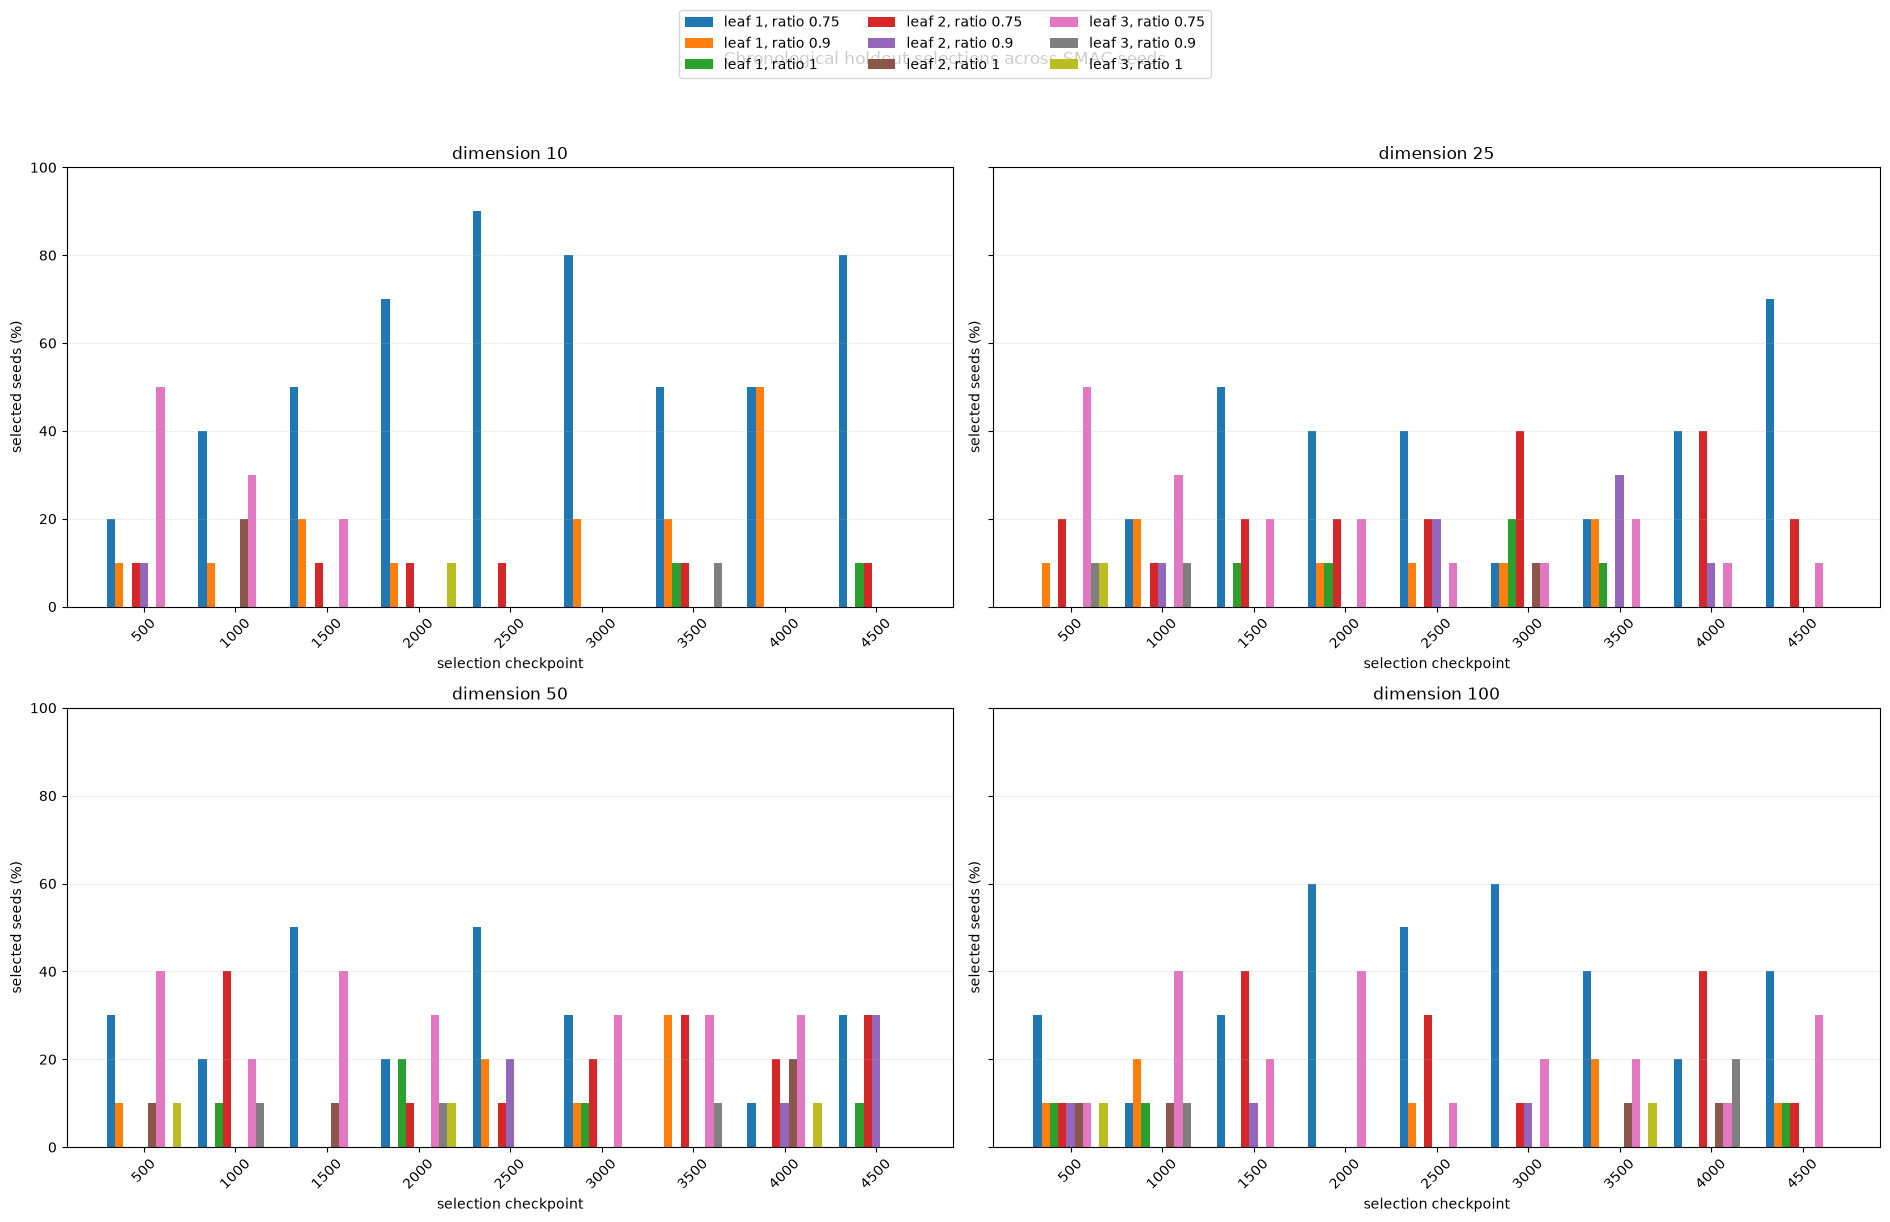

In [8]:
# Holdout-policy selection frequencies across SMAC seeds.
# Each table is percentage of available seeds selecting the leaf x feature-ratio pair.
holdout_selections = pd.DataFrame(selection_rows)
holdout_checkpoints = list(range(500, 5000, 500))
leaf_choices = [1, 2, 3]
ratio_choices = [0.75, 0.90, 1.00]
combo_choices = [(leaf, ratio) for leaf in leaf_choices for ratio in ratio_choices]
combo_labels = [f'leaf {leaf}, ratio {ratio:g}' for leaf, ratio in combo_choices]
if holdout_selections.empty:
    print('No completed holdout selections found yet.')
else:
    holdout_selections['combo'] = holdout_selections.apply(lambda row: f"leaf {int(row['min_samples_leaf'])}, ratio {float(row['feature_ratio']):g}", axis=1)
    fig, axes = plt.subplots(2, 2, figsize=(19, 12), sharey=True)
    bar_width = 0.09
    x = np.arange(len(holdout_checkpoints))
    for ax, dimension in zip(axes.flat, (10, 25, 50, 100)):
        data = holdout_selections[holdout_selections.dimension == dimension]
        percentages = pd.DataFrame(0.0, index=holdout_checkpoints, columns=combo_labels)
        for checkpoint in holdout_checkpoints:
            at_checkpoint = data[data.checkpoint == checkpoint]
            denominator = at_checkpoint.seed.nunique()
            if denominator:
                counts = at_checkpoint.combo.value_counts() / denominator * 100
                percentages.loc[checkpoint, counts.index] = counts.values
        for combo_index, label in enumerate(combo_labels):
            ax.bar(x + (combo_index - 4) * bar_width, percentages[label].values, width=bar_width, label=label)
        ax.set_title(f'dimension {dimension}')
        ax.set_xticks(x, [str(cp) for cp in holdout_checkpoints], rotation=45)
        ax.set_xlabel('selection checkpoint')
        ax.set_ylabel('selected seeds (%)')
        ax.set_ylim(0, 100)
        ax.grid(axis='y', alpha=.2)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(.5, 1.02))
    fig.suptitle('Chronological holdout selections across SMAC seeds')
    fig.tight_layout(rect=(0, 0, 1, .94))

    # Four separate percentage tables, one for each objective dimension.
    for dimension in (10, 25, 50, 100):
        data = holdout_selections[holdout_selections.dimension == dimension]
        table = pd.DataFrame(0.0, index=combo_labels, columns=holdout_checkpoints)
        for checkpoint in holdout_checkpoints:
            at_checkpoint = data[data.checkpoint == checkpoint]
            denominator = at_checkpoint.seed.nunique()
            if denominator:
                counts = at_checkpoint.combo.value_counts() / denominator * 100
                for label, percentage in counts.items():
                    table.loc[label, checkpoint] = percentage
        print(f'\nDimension {dimension}: percentage of available SMAC seeds selecting each combination')
        display(table.round(1))